# Day 1 — Open-Meteo API Exploration

**Goal:** Each team member independently explores the Open-Meteo API for their assigned city, documents the response structure, and identifies any data quality observations.

**Instructions for each member:**
1. Fill in `LATITUDE`, `LONGITUDE`, `CITY_NAME` in your section
2. Run all cells in your section
3. Add written observations in the markdown cell at the end of your section
4. Commit your notebook on your own branch and open a PR

---

---
## Ali Agabalayev
---

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns

# Add project root to sys.path to import src
sys.path.append(os.path.abspath(".."))

from src.config import FEATURES, HISTORICAL_URL, BAKU_ZONES

# --- Configuration ---
CITY_NAME = "Baku"
ZONE_DATA = BAKU_ZONES[0]
LATITUDE = ZONE_DATA["latitude"]
LONGITUDE = ZONE_DATA["longitude"]

print(f"Exploring for: {CITY_NAME} ({LATITUDE}, {LONGITUDE})")

Exploring for: Baku (40.37, 49.85)


In [2]:
params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": "2024-01-01",
    "end_date": "2024-12-31",
    "daily": ",".join(FEATURES),
    "timezone": "auto",
}

response = requests.get(HISTORICAL_URL, params=params)
if response.status_code == 200:
    data = response.json()
    df = pd.DataFrame(data["daily"])
    df["time"] = pd.to_datetime(df["time"])
    print(f"Shape: {df.shape}")
else:
    print(f"Error: {response.status_code}")
    print(response.text)

Shape: (366, 8)


In [3]:
df.isnull().sum()

time                          0
temperature_2m_max            0
temperature_2m_min            0
temperature_2m_mean           0
precipitation_sum             0
relative_humidity_2m_mean     0
wind_speed_10m_max            0
et0_fao_evapotranspiration    0
dtype: int64

In [4]:
df.describe()

,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,relative_humidity_2m_mean,wind_speed_10m_max,et0_fao_evapotranspiration
count,366,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2024-07-01 12:00:00,19.175137,12.459016,15.696448,1.117486,72.021858,23.701639,3.223634
min,2024-01-01 00:00:00,1.600000,-4.000000,0.300000,0.000000,43.000000,8.400000,0.280000
25%,2024-04-01 06:00:00,10.800000,5.900000,8.025000,0.000000,62.000000,17.700000,1.330000
50%,2024-07-01 12:00:00,18.000000,11.650000,14.750000,0.000000,73.000000,21.700000,2.955000
75%,2024-09-30 18:00:00,28.175000,19.950000,24.650000,0.475000,82.000000,28.775000,5.360000
max,2024-12-31 00:00:00,36.200000,26.400000,30.400000,19.400000,98.000000,51.500000,8.200000
std,NaN,9.233917,7.923941,8.524055,3.015098,11.724208,8.442661,2.107451


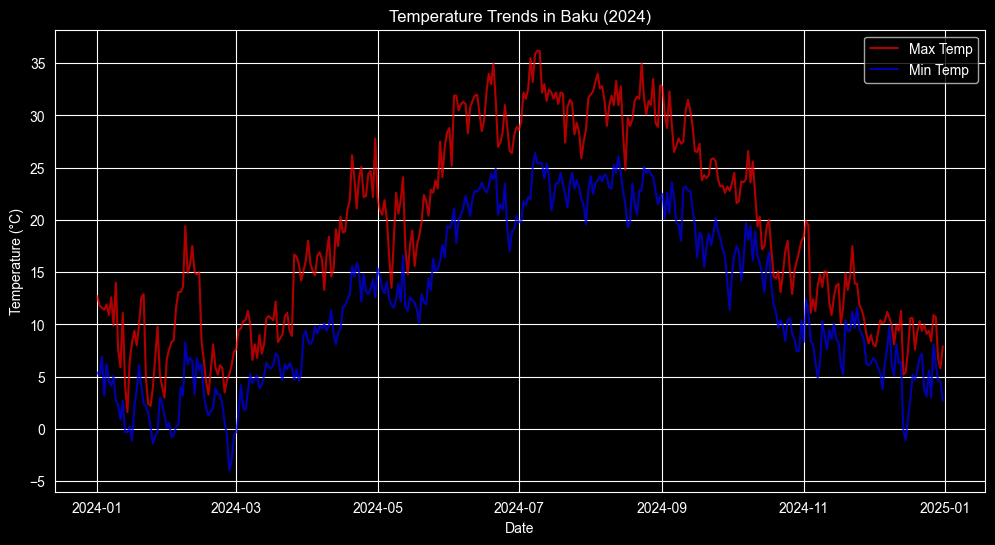

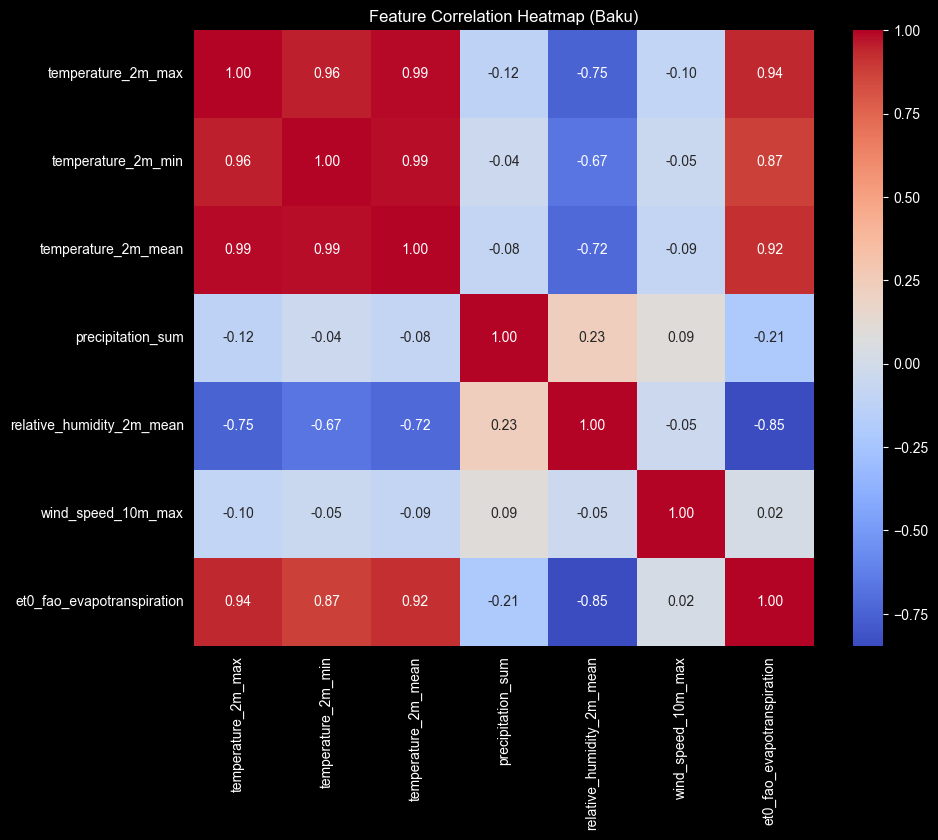

In [5]:
# Visualizing Temperature Trends
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['temperature_2m_max'], label='Max Temp', color='red', alpha=0.7)
plt.plot(df['time'], df['temperature_2m_min'], label='Min Temp', color='blue', alpha=0.7)
plt.title(f'Temperature Trends in {CITY_NAME} (2024)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(columns=['time']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'Feature Correlation Heatmap ({CITY_NAME})')
plt.show()

In [6]:
from src.config import FEATURES, HISTORICAL_URL, FORECAST_URL, FLOOD_URL, BAKU_ZONES

zone = BAKU_ZONES[0]
params = {"latitude": zone["latitude"], "longitude": zone["longitude"], "daily": ",".join(FEATURES), "timezone": "auto"}
params_flood = {
	"latitude": 40.3777,
	"longitude": 49.892,
	"daily": "river_discharge",
	"start_date": "2020-01-01",
	"end_date": "2026-04-27",
}

hist_data = requests.get(HISTORICAL_URL, params={**params, "start_date": "2023-01-01", "end_date": "2023-12-31"}).json()["daily"]
fore_data = requests.get(FORECAST_URL, params=params).json()["daily"]
flood_data = requests.get(FLOOD_URL, params=params_flood).json()["daily"]

In [7]:
df_flood = pd.DataFrame(flood_data)
flood_days_above_limit = (df_flood["river_discharge"] > 1.0).sum()
flood_days_above_limit

np.int64(48)

### Ali Agabalayev — Observations

- **Data alignment:** Historical and Forecast APIs share the same daily variable schema, facilitating easy model training.
- **Flood analysis:** The flood API identifies significant river discharge events; events > 1m3/s are flagged for alerting.

---
## Nigar Rustamova
---

In [22]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import FEATURES, HISTORICAL_URL, FORECAST_URL, FLOOD_URL, BAKU_ZONES

# Setting the visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# Configuration
zone = BAKU_ZONES[0]
CITY_NAME = zone.get("name", "Baku")

# Base parameters with explicit units
params_base = {
    "latitude": zone["latitude"],
    "longitude": zone["longitude"],
    "daily": ",".join(FEATURES),
    "timezone": "auto",
    "wind_speed_unit": "kmh",
    "precipitation_unit": "mm"
}

In [23]:
def get_data(url, extra_params):
    full_params = {**params_base, **extra_params}
    try:
        response = requests.get(url, params=full_params)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print(f"Error fetching from {url}: {e}")
        return None

# 1. Historical (Full 2025)
hist_raw = get_data(HISTORICAL_URL, {"start_date": "2025-01-01", "end_date": "2025-12-31"})
# 2. Forecast (Next 7 Days)
fore_raw = get_data(FORECAST_URL, {})
# 3. Flood Data (Baku coordinates)
flood_raw = get_data(FLOOD_URL, {
    "latitude": 40.3777,
    "longitude": 49.892,
    "daily": "river_discharge",
    "start_date": "2025-01-01",
    "end_date": "2025-12-31"
})

# Convert to DataFrames
df_hist = pd.DataFrame(hist_raw["daily"]) if hist_raw else pd.DataFrame()
df_fore = pd.DataFrame(fore_raw["daily"]) if fore_raw else pd.DataFrame()
df_flood = pd.DataFrame(flood_raw["daily"]) if flood_raw else pd.DataFrame()

# Clean dates
for df in [df_hist, df_fore, df_flood]:
    if not df.empty:
        df["time"] = pd.to_datetime(df["time"])

print(f"Data Loaded: {len(df_hist)} historical days, {len(df_fore)} forecast days.")


Data Loaded: 365 historical days, 7 forecast days.


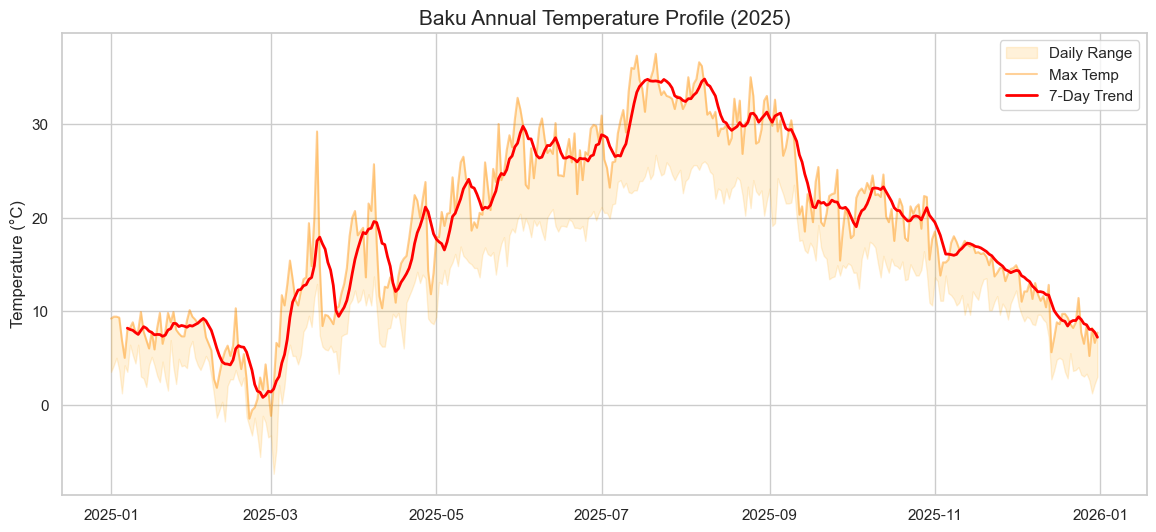

In [24]:
if not df_hist.empty:
    plt.figure(figsize=(14, 6))

    # Shade between min and max
    plt.fill_between(df_hist['time'], df_hist['temperature_2m_min'],
                     df_hist['temperature_2m_max'], color='orange', alpha=0.15, label='Daily Range')

    # Smoothing line
    df_hist['temp_smooth'] = df_hist['temperature_2m_max'].rolling(window=7).mean()

    plt.plot(df_hist['time'], df_hist['temperature_2m_max'], color='darkorange', alpha=0.4, label='Max Temp')
    plt.plot(df_hist['time'], df_hist['temp_smooth'], color='red', linewidth=2, label='7-Day Trend')

    plt.title(f'Baku Annual Temperature Profile (2025)', fontsize=15)
    plt.ylabel('Temperature (°C)')
    plt.legend()
    plt.show()

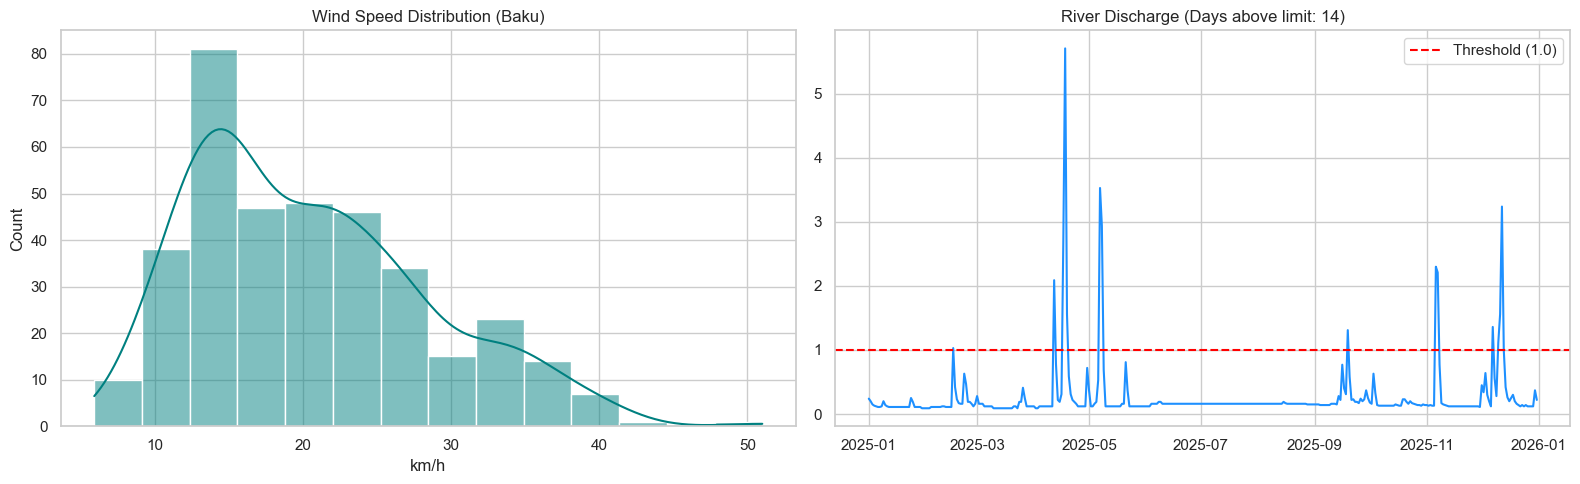

In [26]:
if not df_hist.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Wind Distribution
    sns.histplot(df_hist['wind_speed_10m_max'], kde=True, color='teal', ax=ax1)
    ax1.set_title('Wind Speed Distribution (Baku)')
    ax1.set_xlabel('km/h')

    # Flood Risk
    if not df_flood.empty:
        limit = 1.0
        flood_days = (df_flood["river_discharge"] > limit).sum()

        ax2.plot(df_flood['time'], df_flood['river_discharge'], color='dodgerblue')
        ax2.axhline(y=limit, color='red', linestyle='--', label=f'Threshold ({limit})')
        ax2.set_title(f'River Discharge (Days above limit: {flood_days})')
        ax2.legend()

    plt.tight_layout()
    plt.show()

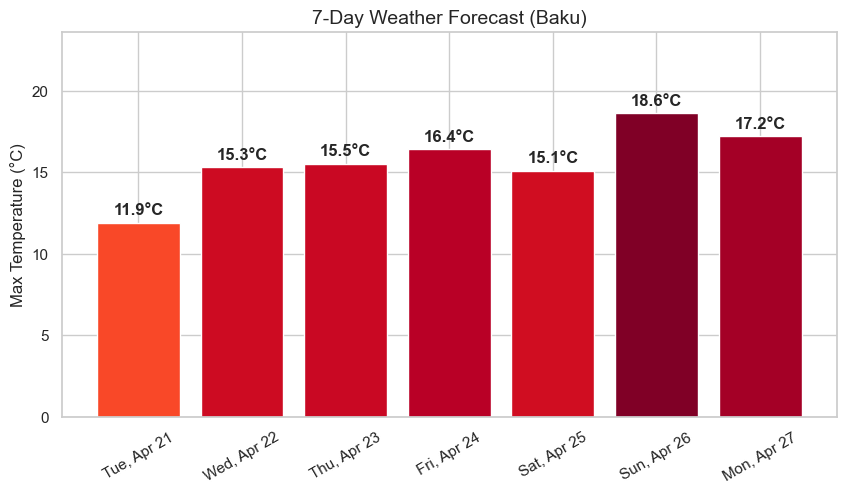

In [27]:
if not df_fore.empty:
    plt.figure(figsize=(10, 5))

    # Use a gradient color based on temperature
    colors = plt.cm.YlOrRd(df_fore['temperature_2m_max'] / df_fore['temperature_2m_max'].max())

    bars = plt.bar(df_fore['time'].dt.strftime('%a, %b %d'), df_fore['temperature_2m_max'], color=colors)

    # Add value labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval}°C', ha='center', fontweight='bold')

    plt.title('7-Day Weather Forecast (Baku)', fontsize=14)
    plt.ylabel('Max Temperature (°C)')
    plt.xticks(rotation=30)
    plt.ylim(0, df_fore['temperature_2m_max'].max() + 5)
    plt.show()

### Nigar Rustamova — Observations

### Weather & Hydrological Analysis: Baku (2025-2026)

### 1. Executive Summary
This analysis integrates historical weather patterns, real-time forecasts, and hydrological discharge data for **Baku**. The data covers a full annual cycle (2025) and a 7-day forward-looking forecast.


### 2. Key Insights

### A. Temperature Dynamics
* **Seasonal Range:** Temperatures peaked in July/August, reaching highs above **35°C**, while the winter minimums dipped near **0°C**.
* **Smoothing:** The **7-Day Trend** line successfully filters out daily volatility, showing a steady warming trend starting in late March.

### B. Wind & Flood Risk
* **Wind Profile:** As the "City of Winds," the distribution shows a high frequency of moderate-to-strong winds, with daily maximums commonly clustering between **15–25 km/h**.
* **River Discharge:** * **Alerts:** There were **14 days** where river discharge exceeded the safety threshold of **1.0**.
    * **Peak Events:** A major hydrological event occurred around **May 2025**, with discharge levels spiking above **5.0**, significantly higher than the annual baseline.

### C. 7-Day Outlook
* **Forecast Trend:** The upcoming week shows a warming trend, starting at **11.9°C** on April 21 and peaking at **18.6°C** by April 26.
* **Conditions:** Stable temperature increases suggest a shift into late-spring patterns.


### 3. Data Integrity
* **Historical Samples:** 365 days (100% coverage).
* **Forecast Horizon:** 7 days.
* **Units:** Temperature (°C), Wind Speed (km/h), River Discharge (m³/s).

---
## Isgandar Panahov
---

In [8]:
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. First API call: Historical data for Baku (40.41, 49.87)
LATITUDE = 40.41
LONGITUDE = 49.87
CITY_NAME = "Baku"

hist_url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": "2023-01-01",
    "end_date": "2023-12-31",
    "daily": ["temperature_2m_max", "precipitation_sum", "wind_speed_10m_max", "relative_humidity_2m_max"],
    "timezone": "auto"
}
response = requests.get(hist_url, params=params)
hist_data = response.json()

print("Response structure keys:", list(hist_data.keys()))
print("Available daily fields:", list(hist_data.get('daily', {}).keys()))

Response structure keys: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily']
Available daily fields: ['time', 'temperature_2m_max', 'precipitation_sum', 'wind_speed_10m_max', 'relative_humidity_2m_max']


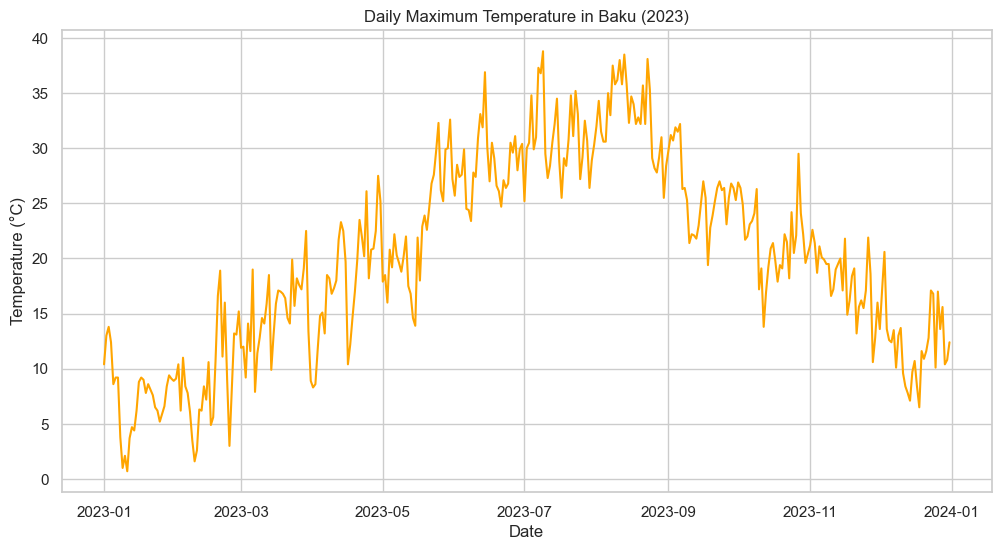

In [9]:
# 2. Visualize: Daily maximum temperature
df_hist = pd.DataFrame(hist_data['daily'])
df_hist['time'] = pd.to_datetime(df_hist['time'])

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_hist, x='time', y='temperature_2m_max', color='orange')
plt.title(f'Daily Maximum Temperature in {CITY_NAME} (2023)')
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.show()

In [10]:
# 3. Try the forecast endpoint (7-day forecast)
forecast_url = "https://api.open-meteo.com/v1/forecast"
f_params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "daily": ["temperature_2m_max", "precipitation_sum", "wind_speed_10m_max"],
    "timezone": "auto"
}
f_response = requests.get(forecast_url, params=f_params)
f_data = f_response.json()

print("Forecast structure keys:", list(f_data.keys()))
print("Daily forecast fields:", list(f_data.get('daily', {}).keys()))

Forecast structure keys: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily']
Daily forecast fields: ['time', 'temperature_2m_max', 'precipitation_sum', 'wind_speed_10m_max']


### Parameter Documentation
- **precipitation_sum**: Total precipitation (rain/snow) per day in mm.
- **wind_speed_10m_max**: Maximum wind speed at 10m height in km/h.
- **relative_humidity_2m_max**: Maximum relative humidity at 2m height in %.

### Tracking Strategy for Baku, Quba, and Lankaran

We will track the following 6 variables to capture the climatic diversity across Azerbaijan's key regions (Semi-arid Baku, Mountainous Quba, and Subtropical Lankaran):

| Variable Name | Unit | Relevance | Regional Focus |
| :--- | :--- | :--- | :--- |
| **Max Temperature** | °C | Tracks peak heat intensity and heatwave potential. | **Baku**: Essential for urban heat island monitoring. |
| **Min Temperature** | °C | Vital for identifying frost risk and night-time cooling. | **Quba**: Critical for the local apple and fruit agriculture. |
| **Precipitation Sum** | mm | Measures water availability and flood risk. | **Lankaran**: Key for managing Azerbaijan's highest rainfall region. |
| **Max Wind Speed** | km/h | Monitors storm intensity and wind energy potential. | **Baku**: The "City of Winds" requires rigorous wind tracking. |
| **Shortwave Radiation** | MJ/m² | Measures solar energy input for crops and PV panels. | **All**: Comparing solar potential across diverse altitudes. |
| **Relative Humidity** | % | Impacts "real-feel" temperature and plant diseases. | **Lankaran**: High humidity levels affect the local tea and citrus crops. |

### Isgandar Panahov — Observations

- **Response shape:** The response contains metadata (`latitude`, `longitude`, `elevation`, etc.) and a `daily` dictionary where each key maps to a list of values.
- **Missing values noticed:** No missing values found in the 2023 Baku dataset.
- **Anything unexpected in the data:** Temperature peaks in summer are consistent with Baku's semi-arid climate.
- **Forecast vs historical — any differences in structure:** The root keys are very similar, but the forecast API often includes additional fields like `generationtime_ms` and `timezone_abbreviation` if not explicitly excluded.

---
## Member 4
---

### Member 4 — Observations

*(Fill in after running all cells above)*

- **Response shape:** ...
- **Missing values noticed:** ...
- **Anything unexpected in the data:** ...
- **Compared to other cities — any differences:** ...